In [1]:
# use float64'
from jax import config
config.update("jax_enable_x64", True)

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
import optax

from hybrid_models.hh import *
from hybrid_models.hh import integrate
from hybrid_models.utils import tree_path_of_leaves, tree_set_with_path, tree_filter_by_path, Dataset
from hybrid_models.transforms import ParamTransform, LogisticTransform, ModelParamTransform
import equinox as eqx

import matplotlib.pyplot as plt

import os
import sys
sys.path.append('../')
import pickle

from scripts.configs import *
config = train_hybrid_on_multicomp()
import diffrax

import json

import numpy as np
import pandas as pd

FULL_WIDTH = 5.521
HALF_WIDTH = FULL_WIDTH / 2
plt.style.use("../.matplotlibrc")

In [3]:
base_config = generate_hh_multi_spike()
hh_true = base_config.hh_model
hh_true = hh_true.set(base_config.static_params)
u0 = hh_true.init(0.0, base_config.u_init)
ts = jnp.arange(0, 50.0, 0.1)

In [4]:
@eqx.filter_vmap(in_axes=(None, 0, None, None))
def v_integrate(model, params, u0, ts):
    _model = model.set(params)  # this should only set static params!
    t, x = integrate(_model, ts, u0)
    return t, x

In [5]:
# # EXP_NAME = "train_k_2026_04_30_17_12_18_364283"
# EXP_NAME = "results/train_k_2026_04_28_13_21_38_805364"

config = train_hybrid_on_hh_k()
val_data = Dataset.from_file("../" + config.val_fpath)
v_val = val_data.Y["v"][0]

EXP_DIR = "../results/sweeps/hh_channel_obs_noise_sweep4/"
json_files = [f for f in os.listdir(EXP_DIR) if f.endswith(".json")]

rmse = lambda x, y: jnp.sqrt(jnp.mean((x - y) ** 2))

df = pd.DataFrame(columns=["obs_noise", "rmse", "pred", "fpath", "width", "depth", "act"])
for json_file in json_files:
    fpath = os.path.join(EXP_DIR, json_file)
    with open(fpath, "r") as f:
        loaded_data = json.load(f)

    with open(fpath.replace(".json", ".log"), "r") as f:
        logf_header = f.read()[:2000]
        activation_index = logf_header.find("'activation': ") + len("'activation': ")
        act_name = logf_header[activation_index:].split(" ")[3]

    val_data = loaded_data["validation_data"]
    v_noise = np.array(val_data["val"]["v"][0])
    v_pred = np.array(val_data["pred"]["v"][0])

    rmse_val = rmse(v_val, v_pred)
    width = loaded_data["channel_model_kwargs"]["width_size"]
    depth = loaded_data["channel_model_kwargs"]["depth_size"]
    noise = loaded_data["obs_noise"]

    df.loc[len(df)] = [noise, rmse_val, v_pred, fpath, width, depth, act_name]

# sort fpaths for rmse, then give me only the best one for zero noise
df = df.sort_values("rmse").reset_index(drop=True)
top_k_models = df[df["obs_noise"] == 0]

idx = 0
EXP_NAME = top_k_models["fpath"].values[idx].replace(".json", "")[3:] # skip "../"

with open(f"../{EXP_NAME}.json", "r") as f:
    loaded_data = json.load(f)
data = Dataset.from_file(f"../{loaded_data['train_fpath']}")

print(top_k_models[["width", "depth", "rmse", "act"]].iloc[idx])

width                    32
depth                     2
rmse     0.6254967896680623
act                    tanh
Name: 6, dtype: object


In [6]:
config = train_hybrid_on_hh_k()
hh_base = config.hh_model
channel_model = config.ChannelModel(key=jr.PRNGKey(0), **config.channel_model_kwargs)
init_model = hh_base.insert(channel_model)
init_model = init_model.set(config.init_params)

hh_node = eqx.tree_deserialise_leaves(f"../{EXP_NAME}.eqx", init_model)
u0 = hh_node.init(0.0, config.u_init)

_, u_init = integrate(init_model, ts, u0)
_, u_true = integrate(hh_true, ts, u0)

ts_long = jnp.arange(0, 100.0, 0.1)
ext_long = {".externals['i_ext'].end": 95.0}

u0_base = hh_base.init(0.0, base_config.u_init)
ts_long, u_base_long = integrate(hh_base.set(ext_long), ts_long, u0_base)
ts_long, u_pred_long = integrate(hh_node.set(ext_long), ts_long, u0)
ts_long, u_true_long = integrate(hh_true.set(ext_long), ts_long, u0)

amps = {".externals['i_ext'].amp": jnp.array([9.0, 11.0, 13, 15.0, 17, 19.0, 21.0])}
_, u_ampl_true = v_integrate(hh_true, amps, u0, ts)
_, u_ampl_pred = v_integrate(hh_node, amps, u0, ts)

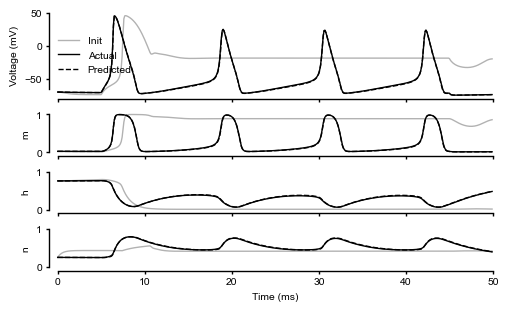

In [7]:
val_data = loaded_data["validation_data"]
# ts = jnp.array(val_data["ts"])
ys_val = jax.tree.map(lambda x: jnp.array(x), val_data["val"], is_leaf= lambda x: isinstance(x, list))
ys_pred = jax.tree.map(lambda x: jnp.array(x), val_data["pred"], is_leaf= lambda x: isinstance(x, list))

fig, axes = plt.subplots(4, 1, figsize=(5,3), sharex=True, layout="constrained", height_ratios=[2,1,1,1])

axes[0].plot(ts, u_init["v"], label="Init", c="k", alpha=0.3)
axes[0].plot(ts, u_true["v"].T, label="Actual", c="k")
axes[0].plot(ts, ys_pred["v"].T, label="Predicted", ls="--", c="k")
axes[0].set_ylabel("Voltage (mV)")
axes[0].legend()

axes[1].plot(ts, u_init["m"], label="Init", c="k", alpha=0.3)
axes[1].plot(ts, u_true["m"].T, c="k")
axes[1].plot(ts, ys_pred["m"].T, c="k", ls="--")
axes[1].set_ylabel("m")
axes[1].set_ylim(-0.1, 1.05)

axes[2].plot(ts, u_init["h"], label="Init", c="k", alpha=0.3)
axes[2].plot(ts, u_true["h"].T, c="k")
axes[2].plot(ts, ys_pred["h"].T, c="k", ls="--")
axes[2].set_ylabel("h")
axes[2].set_ylim(-0.1, 1.05)

axes[3].plot(ts, u_init["n"], label="Init", c="k", alpha=0.3)
axes[3].plot(ts, u_true["n"].T, c="k")
axes[3].plot(ts, ys_pred["n"].T, c="k", ls="--")
axes[3].set_ylabel("n")
axes[3].set_ylim(-0.1, 1.05)

axes[0].spines["bottom"].set_bounds(0, 50)
axes[0].spines["left"].set_bounds(-65, 50)
axes[0].set_xlim(-1.0, 51) # shared x-axis, so set on all

for ax in axes[1:]:
    ax.spines["bottom"].set_bounds(0, 50)
    ax.spines["left"].set_bounds(0, 1)

axes[3].set_xlabel("Time (ms)")
plt.show()

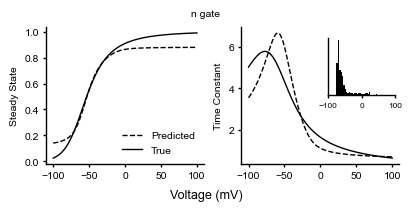

In [8]:
v_range = {"v": jnp.linspace(-100, 100, 100)} # example input for gate computation
ss_pred, tau_pred = eqx.filter_vmap(hh_node.channels["node"]._compute_gates)(0.0, v_range)
ss_true = eqx.filter_vmap(K().xinf)(0.0, v_range)
tau_true = eqx.filter_vmap(K().tau)(0.0, v_range)

fig, axes = plt.subplots(1, 2, figsize=(4, 2), layout="constrained", sharex=True)
axes[0].plot(v_range["v"], ss_pred["n"], label="Predicted", ls="--", c="k")
axes[0].plot(v_range["v"], ss_true["n"], label="True", c="k")
axes[0].legend()
axes[0].set_ylabel("Steady State")
fig.suptitle("n gate")
fig.supxlabel("Voltage (mV)")

axes[1].plot(v_range["v"], tau_pred["n"], label="Predicted", ls="--", c="k")
axes[1].plot(v_range["v"], tau_true["n"], label="True", c="k")
axes[1].set_ylabel("Time Constant")

ax_inset = axes[1].inset_axes([0.55, 0.5, 0.42, 0.42])  # [x0, y0, width, height] in axes fraction
ax_inset.hist(np.ravel(data.Y["v"]), bins=np.linspace(-100, 100, 50), color="k")
ax_inset.set_xlim(-100, 100)
ax_inset.set_xticks([-100, 0, 100])
ax_inset.set_yticks([])
ax_inset.tick_params(labelsize=6)

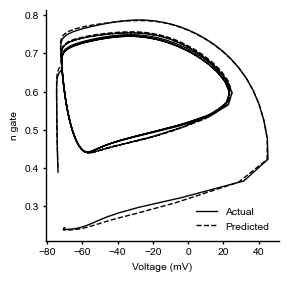

In [9]:
fig, axes = plt.subplots(figsize=(3, 3))

axes.plot(u_true["v"], u_true["n"].T, label="Actual", c="k")
axes.plot(ys_pred["v"].T, ys_pred["n"].T, label="Predicted", ls="--", c="k")
axes.set_xlabel("Voltage (mV)")
axes.set_ylabel("n gate")
axes.legend()

(-79.0, 45.0)

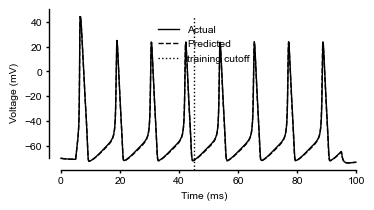

In [10]:
fig, axes = plt.subplots(figsize=(4, 2))
axes.plot(ts_long, u_true_long["v"].T, label="Actual", c="k")
axes.plot(ts_long, u_pred_long["v"].T, label="Predicted", ls="--", c="k")
axes.axvline(45.0, c="k", ls=":", label="training cutoff")
axes.set_xlabel("Time (ms)")
axes.set_ylabel("Voltage (mV)")
axes.legend()

axes.spines["bottom"].set_bounds(0, 100)
axes.spines["left"].set_bounds(-70, 50)
axes.set_xlim(-4.0, 101) # shared x-axis, so set on all
axes.set_ylim(-79.0, 45) # shared x-axis, so set on all

Text(-2.8, -89.79192382572631, '50 mV')

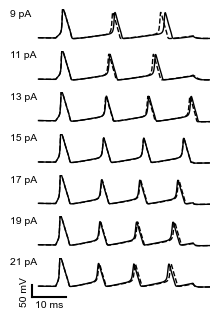

In [11]:
n_traces = u_ampl_true["v"].shape[0]
fig, axes = plt.subplots(
    n_traces,
    1,
    figsize=(2, 3),
    layout="constrained",
    sharex=True,
    sharey=True,
)
fig.set_constrained_layout_pads(h_pad=0.0, w_pad=0.0, hspace=0.0, wspace=0.0)

axes = np.atleast_1d(axes)

amps_list = list(amps.values())[0]
for i, (ax, amp) in enumerate(zip(axes.flat, amps_list)):
    ax.plot(ts, u_ampl_true["v"][i], c="k")
    ax.plot(ts, u_ampl_pred["v"][i], ls="--", c="k")
    ax.set_ylim(-80, 42)

    ax.text(
        -0.1,
        0.9,
        f"{float(amp):g} pA",
        transform=ax.transAxes,
        ha="left",
        va="center",
    )

    if i < n_traces - 1:
        ax.axis("off")
    else:
        # keep last panel available for scale bars
        ax.axis("off")
        ax.set_xlim(float(ts.min()) - 3.0, float(ts.max()))
        ax.set_ylim(-120, 42)

# Scale bars (bottom-left of last panel)
ax_sb = axes[-1]
x_bar_ms = 10.0
y_bar_mv = 50.0

x0 = float(ts.min()) - 2.0
vmin = float(jnp.minimum(u_ampl_true["v"].min(), u_ampl_pred["v"].min()))
y0 = vmin - 40.0

ax_sb.plot([x0, x0 + x_bar_ms], [y0, y0], c="k", lw=1.5)  # time bar
ax_sb.plot([x0, x0], [y0, y0 + y_bar_mv], c="k", lw=1.5)  # voltage bar
ax_sb.text(x0 + x_bar_ms / 2, y0 - 10.0, f"{x_bar_ms:g} ms", ha="center", va="top")
ax_sb.text(x0 - 0.8, y0 + y_bar_mv / 2, f"{y_bar_mv:g} mV", ha="right", va="center", rotation=90)

# assemble figure

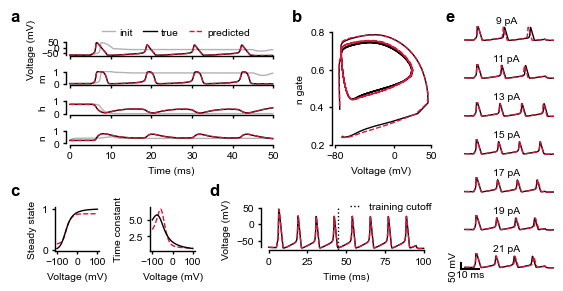

In [34]:
# Composite figure layout:
# a a a b e
# c c d d e
fig = plt.figure(figsize=(FULL_WIDTH, 2.8), layout="constrained")
axd = fig.subplot_mosaic(
    [["a", "a", "a", "b", "e"], ["c", "c", "d", "d", "e"]],
    width_ratios=[2.8, 0.8, 0.4, 1.8, 2.1],
    height_ratios=[2.6, 1.0],
)

def panel_label(ax, label, x=-0.12, y=1.07):
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

# -------------------------
# Shared data prep
# -------------------------
val_data = loaded_data["validation_data"]
ys_val = jax.tree.map(lambda x: jnp.array(x), val_data["val"], is_leaf=lambda x: isinstance(x, list))
ys_pred = jax.tree.map(lambda x: jnp.array(x), val_data["pred"], is_leaf=lambda x: isinstance(x, list))

t_plot = np.asarray(ts).squeeze()

v_init = np.asarray(u_init["v"]).squeeze()
m_init = np.asarray(u_init["m"]).squeeze()
h_init = np.asarray(u_init["h"]).squeeze()
n_init = np.asarray(u_init["n"]).squeeze()

v_true = np.asarray(u_true["v"]).squeeze()
m_true = np.asarray(u_true["m"]).squeeze()
h_true = np.asarray(u_true["h"]).squeeze()
n_true = np.asarray(u_true["n"]).squeeze()

v_pred = np.asarray(ys_pred["v"]).squeeze()
m_pred = np.asarray(ys_pred["m"]).squeeze()
h_pred = np.asarray(ys_pred["h"]).squeeze()
n_pred = np.asarray(ys_pred["n"]).squeeze()

# -------------------------
# Panel a (4 stacked traces)
# -------------------------
gs_a = axd["a"].get_subplotspec().subgridspec(4, 1)
axd["a"].remove()

axes_a = []
for i in range(4):
    ax = fig.add_subplot(gs_a[i, 0])
    if i < 3:
        ax.set_xticklabels([])
    ax.spines["bottom"].set_bounds(0, 50)
    ax.set_xlim(-1.0, 51)
    axes_a.append(ax)
axes_a = np.array(axes_a)

axes_a[0].plot(t_plot, v_init, label="init", c="k", alpha=0.3)
axes_a[0].plot(t_plot, v_true, label="true", c="k")
axes_a[0].plot(t_plot, v_pred, label="predicted", ls="--", c="crimson")
axes_a[0].set_ylabel("Voltage (mV)")
leg = axes_a[0].legend(
    loc=(0.15, 1.05),
    # bbox_to_anchor=(0.0, 1.15),
    ncol=3,
    frameon=False,
    handlelength=1.3,
    handletextpad=0.4,
    columnspacing=1.0,
)
leg.set_in_layout(False)

axes_a[0].spines["left"].set_bounds(-65, 50)
panel_label(axes_a[0], "a", y=2.23, x=-0.22)

axes_a[1].plot(t_plot, m_init, c="k", alpha=0.3)
axes_a[1].plot(t_plot, m_true, c="k")
axes_a[1].plot(t_plot, m_pred, c="crimson", ls="--")
axes_a[1].set_ylabel("m")

axes_a[2].plot(t_plot, h_init, c="k", alpha=0.3)
axes_a[2].plot(t_plot, h_true, c="k")
axes_a[2].plot(t_plot, h_pred, c="crimson", ls="--")
axes_a[2].set_ylabel("h")

axes_a[3].plot(t_plot, n_init, c="k", alpha=0.3)
axes_a[3].plot(t_plot, n_true, c="k")
axes_a[3].plot(t_plot, n_pred, c="crimson", ls="--")
axes_a[3].set_ylabel("n")
axes_a[3].set_xlabel("Time (ms)")

for ax in axes_a[1:]:
    ax.set_ylim(-0.1, 1.05)
    ax.spines["left"].set_bounds(0, 1)

# -------------------------
# Panel b (phase plane)
# -------------------------
ax_b = axd["b"]
ax_b.plot(v_true, n_true, label="True", c="k")
ax_b.plot(v_pred, n_pred, label="Predicted", ls="--", c="crimson")
ax_b.set_xlabel("Voltage (mV)")
ax_b.set_ylabel("n gate")

ax_b.set_xlim(-85, 50)
ax_b.set_ylim(0.2, 0.8)
ax_b.set_yticks([0.2, 0.4, 0.6, 0.8])
ax_b.set_xticks([-80, 0, 50])

ax_b.spines["bottom"].set_bounds(-80, 50)
ax_b.spines["left"].set_bounds(0.2, 0.80)

panel_label(ax_b, "b", x=-0.3)

# -------------------------
# Panel c (gate curves)
# -------------------------
v_range = {"v": jnp.linspace(-100, 100, 100)}
ss_pred, tau_pred = eqx.filter_vmap(hh_node.channels["node"]._compute_gates)(0.0, v_range)
ss_true = eqx.filter_vmap(K().xinf)(0.0, v_range)
tau_true = eqx.filter_vmap(K().tau)(0.0, v_range)

gs_c = axd["c"].get_subplotspec().subgridspec(1, 2)
axd["c"].remove()

axes_c = []
for i in range(2):
    ax = fig.add_subplot(gs_c[0, i], sharex=axes_c[0] if i > 0 else None)
    axes_c.append(ax)
axes_c = np.array(axes_c)

v_plot = np.asarray(v_range["v"])

axes_c[0].plot(v_plot, np.asarray(ss_pred["n"]), label="predicted", ls="--", c="crimson")
axes_c[0].plot(v_plot, np.asarray(ss_true["n"]), label="true", c="k")
axes_c[0].set_xlabel("Voltage (mV)")
axes_c[0].set_ylabel("Steady state")
panel_label(axes_c[0], "c", x=-0.8, y=1.2)

axes_c[1].plot(v_plot, np.asarray(tau_pred["n"]), label="predicted", ls="--", c="crimson")
axes_c[1].plot(v_plot, np.asarray(tau_true["n"]), label="true", c="k")
axes_c[1].set_xlabel("Voltage (mV)")
axes_c[1].set_ylabel("Time constant")

# ax_inset = axes_c[1].inset_axes([0.55, 0.5, 0.42, 0.42])
# ax_inset.hist(np.ravel(data.Y["v"]), bins=np.linspace(-100, 100, 50), color="k")
# ax_inset.set_xlim(-100, 100)
# ax_inset.set_xticks([-100, 0, 100])
# ax_inset.set_yticks([])
# ax_inset.tick_params(labelsize=6)

# -------------------------
# Panel d (long rollout)
# -------------------------
ax_d = axd["d"]
ax_d.plot(ts_long, u_true_long["v"].T, label="true", c="k")
ax_d.plot(ts_long, u_pred_long["v"].T, label="predicted", ls="--", c="crimson")
cutoff_label = ax_d.axvline(45.0, c="k", ls=":", label="training cutoff")
ax_d.set_xlabel("Time (ms)")
ax_d.set_ylabel("Voltage (mV)")
ax_d.spines["bottom"].set_bounds(0, 100)
ax_d.spines["left"].set_bounds(-70, 50)
leg2 = ax_d.legend(handles=[cutoff_label], frameon=False, loc=(0.5, 0.8), handlelength=1)
leg2.set_in_layout(False)
panel_label(ax_d, "d", x=-0.24, y=1.2)

# -------------------------
# Panel e (stacked amplitude traces)
# -------------------------
n_traces = u_ampl_true["v"].shape[0]
gs_e = axd["e"].get_subplotspec().subgridspec(n_traces, 1)
axd["e"].remove()

axes_e = []
for i in range(n_traces):
    ax = fig.add_subplot(
        gs_e[i, 0],
        sharex=axes_e[0] if i > 0 else None,
        sharey=axes_e[0] if i > 0 else None,
    )
    axes_e.append(ax)
axes_e = np.atleast_1d(np.array(axes_e, dtype=object))

amps_list = list(amps.values())[0]
for i, (ax, amp) in enumerate(zip(axes_e.flat, amps_list)):
    ax.plot(ts, u_ampl_true["v"][i], c="k")
    ax.plot(ts, u_ampl_pred["v"][i], ls="--", c="crimson")
    ax.set_ylim(-80, 42)
    ax.set_title(f"{float(amp):g} pA", pad=1)

    # ax.text(
    #     -0.15,
    #     0.9,
    #     f"{float(amp):g} pA",
    #     transform=ax.transAxes,
    #     ha="left",
    #     va="center",
    # )

    if i < n_traces - 1:
        ax.axis("off")
    else:
        ax.axis("off")
        ax.set_xlim(float(ts.min()) - 3.0, float(ts.max()))
        ax.set_ylim(-120, 42)

# Scale bars (bottom-left of last panel)
ax_sb = axes_e[-1]
x_bar_ms = 10.0
y_bar_mv = 50.0

panel_label(axes_e[0], "e", x=-0.05)

# Scale bars on last trace
ax_sb = axes_e[-1]
x_bar_ms = 10.0
y_bar_mv = 50.0
x0 = float(ts.min()) - 2.0
vmin = float(jnp.minimum(u_ampl_true["v"].min(), u_ampl_pred["v"].min()))
y0 = vmin - 10.0

ax_sb.plot([x0, x0 + x_bar_ms], [y0, y0], c="k", lw=1.5)
ax_sb.plot([x0, x0], [y0, y0 + y_bar_mv], c="k", lw=1.5)
ax_sb.text(x0 + x_bar_ms / 2, y0 - 10.0, f"{x_bar_ms:g} ms", ha="center", va="top")
ax_sb.text(x0 - 2.0, y0 + y_bar_mv / 2, f"{y_bar_mv:g} mV", ha="right", va="center", rotation=90)

plt.savefig("../figures/paper/fig3.pdf", dpi=300, transparent=True, bbox_inches="tight")
plt.savefig("../figures/paper/fig3.png", dpi=300, transparent=True, bbox_inches="tight")


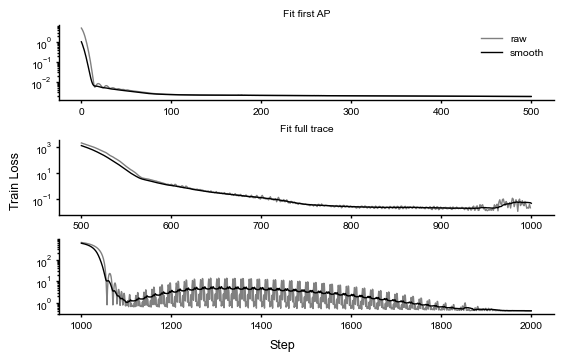

In [8]:
train_losses = jnp.array(loaded_data["train_losses"]) # TODO: Change for val losses
val_losses = jnp.array(loaded_data["val_losses"]) # TODO: Change for val losses
step_counts = jnp.cumsum(jnp.array([strat["max_steps"] for strat in loaded_data["opt_strategy"]]))
step_counts = jnp.concatenate([jnp.array([0]), step_counts])  # include 0 at start for easier indexing

smooth = lambda x: jnp.convolve(x, jnp.ones(20)/20, mode='valid')

fig, axes = plt.subplots(len(step_counts)-1, 1, figsize=(FULL_WIDTH, 3.5), layout="constrained")
for start, end, ax in zip(step_counts[:-1], step_counts[1:], axes):
    strat_losses = train_losses[start:end]
    steps = jnp.arange(start, end)
    smooth_steps = jnp.linspace(start, end, len(smooth(strat_losses)))  # valid points for smoothed curve
    ax.plot(steps, strat_losses, color="grey", label="raw")
    ax.plot(smooth_steps, smooth(strat_losses), color="k", label="smooth")
    ax.set_yscale("log")

axes[0].set_title("Fit first AP")
axes[1].set_title("Fit full trace")
axes[0].legend()

fig.supxlabel("Step")
fig.supylabel("Train Loss")

plt.savefig("../figures/paper/fig3_app2.pdf", dpi=300, transparent=True, bbox_inches="tight")
plt.savefig("../figures/paper/fig3_app2.png", dpi=300, transparent=True, bbox_inches="tight")